# Operational Forecast Cycling

Operational forecast cycling is the process of running a hydraulic model repeatedly as new forecast data arrives, typically updating every 6 hours as HRRR (High-Resolution Rapid Refresh) weather model cycles are released.

This notebook demonstrates how to use ras-commander to automate this workflow:
- Download successive HRRR forecast cycles
- Update HEC-RAS plan simulation dates to match each forecast window
- Execute the model for each cycle with `force_rerun=True`
- Archive results by cycle for comparison
- Compare how forecasts evolve as new data arrives

This pattern is common in flood forecasting operations, emergency management support, and real-time hydrologic monitoring.

**Forecast sequence:** Read this after `915_realtime_forecast_workflow.ipynb` and `918_hms_ras_coupled_forecast.ipynb`. This notebook focuses on repeated execution, cycle archiving, and comparison of forecast results as new forcing data arrive.

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

LOCAL SOURCE MODE: Loading from <workspace>/ras_commander


Loaded: <workspace>\ras_commander\__init__.py


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from ras_commander.precip import PrecipHrrr
from ras_commander.boundaries import CoastalBoundary
from ras_commander import init_ras_project, RasExamples, RasPlan, RasCmdr

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 2)

## What You'll Learn

- Set up a forecast cycling configuration for multiple HRRR cycles
- Update HEC-RAS plan simulation dates to match each forecast window using `RasPlan.update_simulation_date()`
- Use `force_rerun=True` with `RasCmdr.compute_plan()` to ensure fresh execution each cycle
- Handle data availability and latency in an operational setting
- Archive results by cycle for audit trails and comparison
- Compare sequential forecasts to assess convergence and uncertainty

## Example 1: Retrospective Forecast Cycling With Hydrologic Evidence

This example uses four deterministic forecast cycles for the same flood event window. Each cycle represents a new forecast issued six hours apart, with later cycles converging toward the final event timing and rainfall depth.

The comparison tracks decision metrics that matter during an event: predicted crest stage, flood-threshold exceedance duration, and crest timing. Those metrics show whether a new cycle materially changes the operational interpretation.

The precipitation and response functions are self-contained so the notebook can execute without external HRRR GRIB2 downloads. The same cycle metadata is passed to the ras-commander execution template later in the notebook, where a project workflow would write DSS or inline boundary data, call `RasPlan.update_simulation_date()`, and execute `RasCmdr.compute_plan(..., force_rerun=True)`.

### Configuration

In [3]:
# Forecast cycling configuration for a Bald Eagle Creek style riverine basin.
# These values keep the notebook deterministic while preserving realistic units
# and decision thresholds an operational forecaster would review.
config = {
    "project_path": "/path/to/ras_project",
    "ras_version": "6.6",
    "plan_number": "01",
    "forecast_hours": 36,
    "basin_name": "Bald Eagle Creek demonstration basin",
    "basin_bounds": (-77.9, 40.8, -77.3, 41.1),
    "decision_point": "Bald Eagle Creek at Lock Haven forecast point",
    "stage_datum": "ft, local HEC-RAS project datum",
    "drainage_area_sqmi": 105.0,
    "runoff_coefficient": 0.42,
    "time_of_concentration_hr": 5.5,
    "baseflow_cfs": 650.0,
    "action_stage_ft": 14.0,
    "flood_stage_ft": 17.0,
    "major_flood_stage_ft": 21.0,
    "archive_dir": Path("forecast_archive"),
}

base_time = datetime(2024, 7, 15, 0)
valid_times = pd.date_range(base_time, periods=config["forecast_hours"] + 1, freq="1h")
forecast_hours = np.arange(len(valid_times))

cycles = [
    {"date": "20240715", "cycle": 0,  "label": "00z early",  "total_in": 3.55, "center_hr": 18.5, "spread_hr": 5.8, "burst_in": 0.35},
    {"date": "20240715", "cycle": 6,  "label": "06z update", "total_in": 4.20, "center_hr": 16.5, "spread_hr": 5.0, "burst_in": 0.55},
    {"date": "20240715", "cycle": 12, "label": "12z update", "total_in": 4.85, "center_hr": 15.2, "spread_hr": 4.2, "burst_in": 0.85},
    {"date": "20240715", "cycle": 18, "label": "18z latest", "total_in": 4.65, "center_hr": 15.0, "spread_hr": 4.4, "burst_in": 0.78},
]

print("Forecast Cycling Configuration")
print("=" * 72)
print(f"Basin: {config['basin_name']}")
print(f"Drainage area: {config['drainage_area_sqmi']:.1f} sq mi")
print(f"Decision point: {config['decision_point']}")
print(f"Stage datum: {config['stage_datum']}")
print(f"Forecast window: {valid_times[0]:%Y-%m-%d %H:%M} to {valid_times[-1]:%Y-%m-%d %H:%M}")
print(f"Action/flood/major stage thresholds: {config['action_stage_ft']:.1f}, {config['flood_stage_ft']:.1f}, {config['major_flood_stage_ft']:.1f} ft")
print()
print("Forecast cycles:")
for cycle in cycles:
    cycle_start = datetime.strptime(cycle["date"], "%Y%m%d").replace(hour=cycle["cycle"])
    print(
        f"  {cycle['label']:<11} issued {cycle_start:%Y-%m-%d %HZ}: "
        f"{cycle['total_in']:.2f} in basin rainfall, center at hour {cycle['center_hr']:.1f}"
    )

Forecast Cycling Configuration


Basin: Bald Eagle Creek demonstration basin
Drainage area: 105.0 sq mi
Decision point: Bald Eagle Creek at Lock Haven forecast point
Stage datum: ft, local HEC-RAS project datum
Forecast window: 2024-07-15 00:00 to 2024-07-16 12:00
Action/flood/major stage thresholds: 14.0, 17.0, 21.0 ft

Forecast cycles:
  00z early   issued 2024-07-15 00Z: 3.55 in basin rainfall, center at hour 18.5
  06z update  issued 2024-07-15 06Z: 4.20 in basin rainfall, center at hour 16.5
  12z update  issued 2024-07-15 12Z: 4.85 in basin rainfall, center at hour 15.2
  18z latest  issued 2024-07-15 18Z: 4.65 in basin rainfall, center at hour 15.0


### Compute Forecast Hydrology and RAS-Ready Cycle Metadata

The following cells turn each forecast cycle into basin-average precipitation, a routed inflow hydrograph, and a stage response. In a production deployment, the same per-cycle loop is where ras-commander would write DSS/inline boundary data and execute the corresponding HEC-RAS plan.

In [4]:
def forecast_hyetograph(hours, total_in, center_hr, spread_hr, burst_in):
    """Create a smooth basin-average QPF hyetograph in inches/hour."""
    hours = np.asarray(hours, dtype=float)
    broad = np.exp(-0.5 * ((hours - center_hr) / spread_hr) ** 2)
    burst = np.exp(-0.5 * ((hours - (center_hr - 2.0)) / 1.35) ** 2)
    intensity = broad + burst_in * burst
    intensity = intensity / intensity.sum() * total_in
    return intensity


def unit_hydrograph(hours, tc_hr):
    """Dimensionless unit hydrograph used for a compact routing demonstration."""
    t = np.asarray(hours, dtype=float)
    shape = 3.2
    scale = max(tc_hr / shape, 0.1)
    uh = (t + 0.1) ** (shape - 1) * np.exp(-(t + 0.1) / scale)
    uh = uh / uh.sum()
    return uh


def route_to_flow(precip_in_hr, config):
    """Convert basin-average rainfall to an outlet hydrograph in cfs."""
    effective_rain = precip_in_hr * config["runoff_coefficient"]
    uh = unit_hydrograph(np.arange(len(precip_in_hr)), config["time_of_concentration_hr"])
    runoff_in_hr = np.convolve(effective_rain, uh, mode="full")[: len(precip_in_hr)]
    cfs_per_in_hr_sqmi = 645.33
    return config["baseflow_cfs"] + runoff_in_hr * config["drainage_area_sqmi"] * cfs_per_in_hr_sqmi


def stage_from_flow(flow_cfs):
    """Simple monotonic rating curve for demonstration-stage response."""
    return 5.5 + 0.128 * np.sqrt(np.asarray(flow_cfs, dtype=float))


cycle_frames = []
summary_rows = []

for index, cycle in enumerate(cycles, start=1):
    precip = forecast_hyetograph(
        forecast_hours,
        total_in=cycle["total_in"],
        center_hr=cycle["center_hr"],
        spread_hr=cycle["spread_hr"],
        burst_in=cycle["burst_in"],
    )
    flow = route_to_flow(precip, config)
    stage = stage_from_flow(flow)
    cycle_start = datetime.strptime(cycle["date"], "%Y%m%d").replace(hour=cycle["cycle"])
    cycle_label = f"{cycle['date']}_{cycle['cycle']:02d}z"
    cycle_dir = config["archive_dir"] / cycle_label

    frame = pd.DataFrame(
        {
            "valid_time": valid_times,
            "forecast_hour": forecast_hours,
            "cycle_label": cycle["label"],
            "cycle_id": cycle_label,
            "issue_time": cycle_start,
            "precip_in_hr": precip,
            "cumulative_precip_in": np.cumsum(precip),
            "flow_cfs": flow,
            "stage_ft": stage,
        }
    )
    cycle_frames.append(frame)

    peak_idx = int(np.argmax(stage))
    flood_mask = stage >= config["flood_stage_ft"]
    summary_rows.append(
        {
            "cycle": index,
            "cycle_id": cycle_label,
            "label": cycle["label"],
            "issue_time": cycle_start,
            "total_precip_in": precip.sum(),
            "peak_flow_cfs": flow.max(),
            "peak_stage_ft": stage.max(),
            "crest_time": valid_times[peak_idx],
            "hours_above_flood": float(flood_mask.sum()),
            "archive_dir": str(cycle_dir),
            "ras_status": "RAS-ready metadata generated",
        }
    )

forecast_df = pd.concat(cycle_frames, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)
latest_peak = summary_df.iloc[-1]["peak_stage_ft"]
summary_df["peak_stage_delta_vs_latest_ft"] = summary_df["peak_stage_ft"] - latest_peak
summary_df["crest_time_delta_vs_latest_hr"] = (
    summary_df["crest_time"] - summary_df.iloc[-1]["crest_time"]
).dt.total_seconds() / 3600

print("Cycle processing summary")
print("=" * 72)
display(
    summary_df[
        [
            "cycle",
            "label",
            "total_precip_in",
            "peak_flow_cfs",
            "peak_stage_ft",
            "crest_time",
            "hours_above_flood",
            "peak_stage_delta_vs_latest_ft",
            "crest_time_delta_vs_latest_hr",
            "ras_status",
        ]
    ]
)

Cycle processing summary


,cycle,label,total_precip_in,peak_flow_cfs,peak_stage_ft,crest_time,hours_above_flood,peak_stage_delta_vs_latest_ft,crest_time_delta_vs_latest_hr,ras_status
0,1,00z early,3.55,7125.52,16.30,2024-07-15 22:00:00,0.0,-2.88,4.0,RAS-ready metadata generated
1,2,06z update,4.20,9420.80,17.92,2024-07-15 20:00:00,6.0,-1.26,2.0,RAS-ready metadata generated
2,3,12z update,4.85,12302.97,19.70,2024-07-15 19:00:00,9.0,0.51,1.0,RAS-ready metadata generated
3,4,18z latest,4.65,11427.52,19.18,2024-07-15 18:00:00,9.0,0.00,0.0,RAS-ready metadata generated


### Hydrologic and Hydraulic Forecast Evidence

The figures compare rainfall timing, routed flow, stage response, crest convergence, and flood-threshold exceedance duration across forecast cycles.

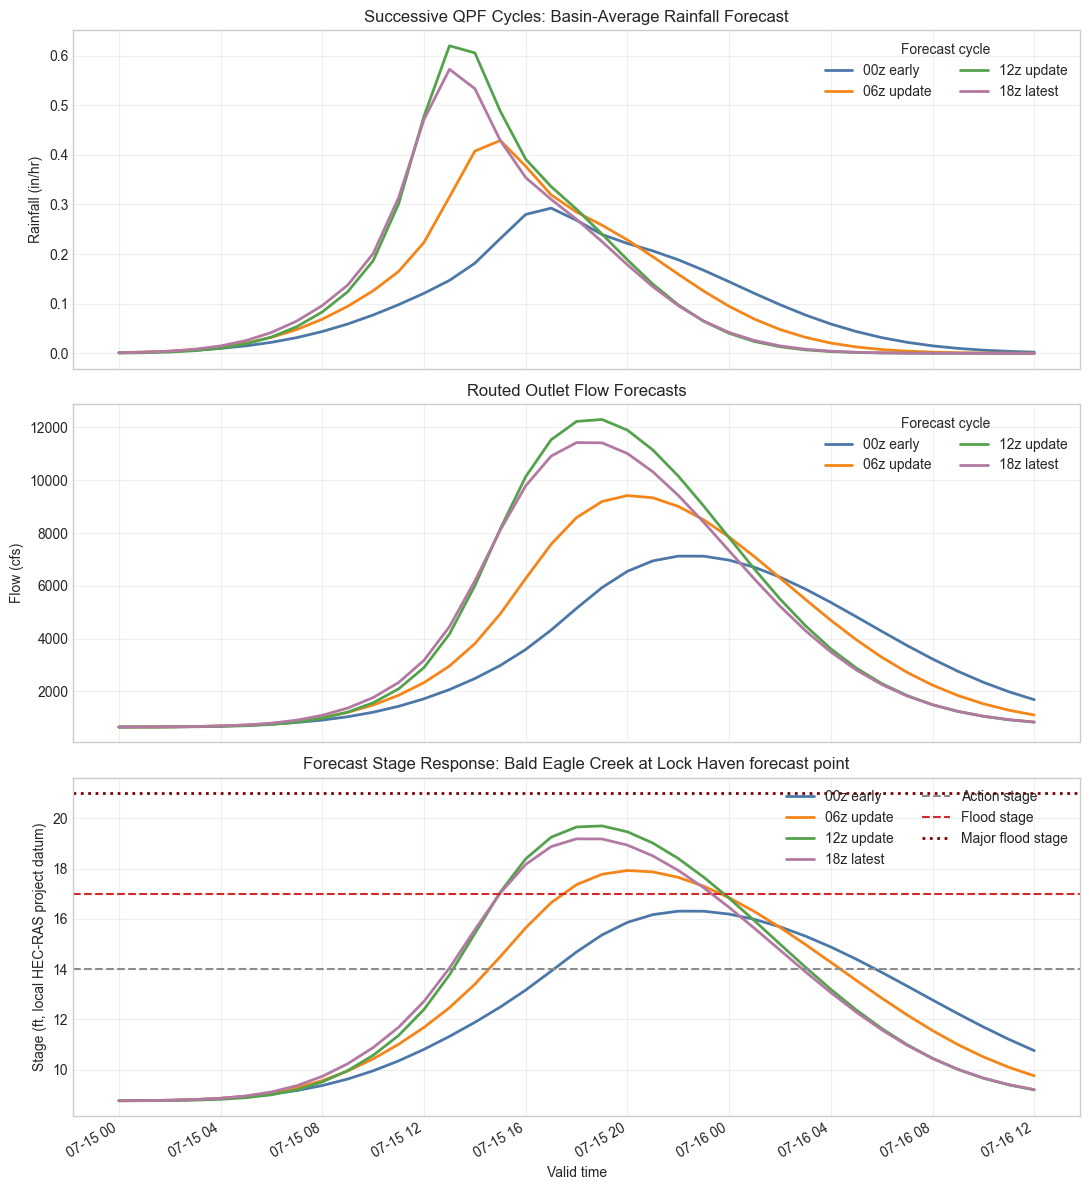

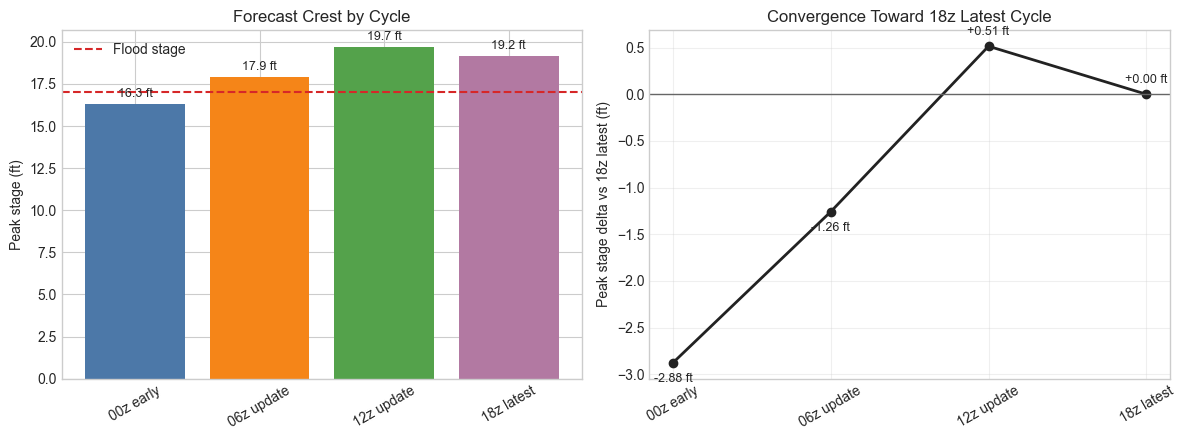

Operational interpretation:
  Decision point: Bald Eagle Creek at Lock Haven forecast point
  Latest cycle crest: 19.18 ft, local HEC-RAS project datum at 2024-07-15 18:00
  Latest cycle peak flow: 11,428 cfs
  Latest cycle flood exceedance duration: 9 hours
  Early-to-latest crest change: -2.88 ft
  Decision value: if the stage delta remains large, emergency managers should treat the forecast as uncertain and keep cycling until convergence improves.


In [5]:
colors = {
    "00z early": "#4C78A8",
    "06z update": "#F58518",
    "12z update": "#54A24B",
    "18z latest": "#B279A2",
}

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

for label, group in forecast_df.groupby("cycle_label", sort=False):
    axes[0].plot(group["valid_time"], group["precip_in_hr"], label=label, color=colors[label], linewidth=2)
    axes[1].plot(group["valid_time"], group["flow_cfs"], label=label, color=colors[label], linewidth=2)
    axes[2].plot(group["valid_time"], group["stage_ft"], label=label, color=colors[label], linewidth=2)

axes[0].set_title("Successive QPF Cycles: Basin-Average Rainfall Forecast")
axes[0].set_ylabel("Rainfall (in/hr)")
axes[0].legend(title="Forecast cycle", ncols=2)

axes[1].set_title("Routed Outlet Flow Forecasts")
axes[1].set_ylabel("Flow (cfs)")
axes[1].legend(title="Forecast cycle", ncols=2)

axes[2].axhline(config["action_stage_ft"], color="#8C8C8C", linestyle="--", linewidth=1.5, label="Action stage")
axes[2].axhline(config["flood_stage_ft"], color="#D62728", linestyle="--", linewidth=1.5, label="Flood stage")
axes[2].axhline(config["major_flood_stage_ft"], color="#7F0000", linestyle=":", linewidth=2, label="Major flood stage")
axes[2].set_title(f"Forecast Stage Response: {config['decision_point']}")
axes[2].set_ylabel(f"Stage ({config['stage_datum']})")
axes[2].set_xlabel("Valid time")
axes[2].legend(ncols=2)

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(summary_df["label"], summary_df["peak_stage_ft"], color=[colors[x] for x in summary_df["label"]])
axes[0].axhline(config["flood_stage_ft"], color="#D62728", linestyle="--", label="Flood stage")
axes[0].set_title("Forecast Crest by Cycle")
axes[0].set_ylabel("Peak stage (ft)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()
for _, row in summary_df.iterrows():
    axes[0].annotate(
        f"{row['peak_stage_ft']:.1f} ft",
        xy=(row['label'], row['peak_stage_ft']),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

axes[1].plot(summary_df["label"], summary_df["peak_stage_delta_vs_latest_ft"], marker="o", color="#222222", linewidth=2)
axes[1].axhline(0, color="#666666", linewidth=1)
axes[1].set_title("Convergence Toward 18z Latest Cycle")
axes[1].set_ylabel("Peak stage delta vs 18z latest (ft)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3)
for _, row in summary_df.iterrows():
    axes[1].annotate(
        f"{row['peak_stage_delta_vs_latest_ft']:+.2f} ft",
        xy=(row['label'], row['peak_stage_delta_vs_latest_ft']),
        xytext=(0, 8 if row['peak_stage_delta_vs_latest_ft'] >= 0 else -14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

fig.tight_layout()
plt.show()

latest = summary_df.iloc[-1]
print("Operational interpretation:")
print(f"  Decision point: {config['decision_point']}")
print(f"  Latest cycle crest: {latest['peak_stage_ft']:.2f} {config['stage_datum']} at {latest['crest_time']:%Y-%m-%d %H:%M}")
print(f"  Latest cycle peak flow: {latest['peak_flow_cfs']:,.0f} cfs")
print(f"  Latest cycle flood exceedance duration: {latest['hours_above_flood']:.0f} hours")
print(f"  Early-to-latest crest change: {summary_df.iloc[0]['peak_stage_delta_vs_latest_ft']:.2f} ft")
print("  Decision value: if the stage delta remains large, emergency managers should treat the forecast as uncertain and keep cycling until convergence improves.")

## Example 2: Automated Pipeline Template

This example provides a reusable function template for operational forecast cycling. The function encapsulates the full cycle workflow and can be called repeatedly as new forecast data becomes available.

### Configurable Forecast Pipeline

In [6]:
def run_forecast_cycle(project_path, ras_version, plan_number,
                       forecast_date, forecast_cycle, forecast_hours,
                       archive_dir, basin_bounds=None, coastal_point=None,
                       execute_ras=False):
    """
    Run or stage a single operational forecast cycle.

    This function keeps the notebook safe by default (`execute_ras=False`).
    In production, set `execute_ras=True` after the cycle-specific boundary
    data have been written to DSS or the unsteady-flow file.
    """
    cycle_start = datetime.strptime(forecast_date, "%Y%m%d").replace(hour=forecast_cycle)
    cycle_end = cycle_start + timedelta(hours=forecast_hours)
    cycle_label = f"{forecast_date}_{forecast_cycle:02d}z"
    cycle_dir = archive_dir / cycle_label

    result = {
        "cycle_label": cycle_label,
        "start": cycle_start,
        "end": cycle_end,
        "archive_dir": cycle_dir,
        "status": "STAGED",
    }

    hrrr_dir = cycle_dir / "hrrr"
    results_dir = cycle_dir / "results"

    # Production hook 1: download HRRR forcing.
    # grib_files = PrecipHrrr.download_forecast(
    #     output_dir=hrrr_dir,
    #     date=forecast_date,
    #     cycle=forecast_cycle,
    #     hours=forecast_hours,
    # )

    # Production hook 2: optional coastal downstream boundary.
    if coastal_point:
        stofs_dir = cycle_dir / "stofs3d"
        # stofs_files = CoastalBoundary.download_stofs3d(stofs_dir)
        # wse_df = CoastalBoundary.extract_wse_at_point(stofs_dir, coastal_point[0], coastal_point[1])
        # CoastalBoundary.generate_stage_bc(wse_df, Path(project_path) / f"project.u{plan_number}", "Downstream")
        result["coastal_boundary"] = "STAGED"

    # Production hook 3: update dates and execute HEC-RAS.
    if execute_ras:
        init_ras_project(project_path, ras_version)
        RasPlan.update_simulation_date(
            plan_number,
            start_date=cycle_start,
            end_date=cycle_end,
        )
        compute_result = RasCmdr.compute_plan(plan_number, force_rerun=True)
        result["status"] = "COMPUTED" if bool(compute_result) else "FAILED"
        result["compute_result"] = compute_result
        result["results_dir"] = results_dir
    else:
        result["status"] = "STAGED_RAS_READY"

    return result


print("Forecast Pipeline Template Function")
print("=" * 72)
print("Use execute_ras=False for dry-run scheduling and execute_ras=True after cycle-specific boundaries are written.")
print("The hydrologic figures above provide the operational comparison; the production hook then computes the matching RAS plan.")

Forecast Pipeline Template Function
Use execute_ras=False for dry-run scheduling and execute_ras=True after cycle-specific boundaries are written.
The hydrologic figures above provide the operational comparison; the production hook then computes the matching RAS plan.


### Running the Cycle Scheduler

The scheduler below uses the same cycle list that produced the hydrologic evidence. It creates RAS-ready metadata for each cycle and leaves HEC-RAS execution disabled by default so the example can run without a local project. Set `execute_ras=True` after boundary data are written in a real project workspace.

In [7]:
archive_dir = Path("forecast_archive")
all_results = []

print("Operational Forecast Schedule")
print("=" * 72)

for cycle_config in cycles:
    result = run_forecast_cycle(
        project_path=config["project_path"],
        ras_version=config["ras_version"],
        plan_number=config["plan_number"],
        forecast_date=cycle_config["date"],
        forecast_cycle=cycle_config["cycle"],
        forecast_hours=config["forecast_hours"],
        archive_dir=archive_dir,
        basin_bounds=config["basin_bounds"],
        execute_ras=False,
    )
    all_results.append(result)
    print(f"  {result['cycle_label']}: {result['status']} -> {result['archive_dir']}")

schedule_df = pd.DataFrame(all_results)
display(schedule_df[["cycle_label", "start", "end", "status", "archive_dir"]])

Operational Forecast Schedule
  20240715_00z: STAGED_RAS_READY -> forecast_archive\20240715_00z
  20240715_06z: STAGED_RAS_READY -> forecast_archive\20240715_06z
  20240715_12z: STAGED_RAS_READY -> forecast_archive\20240715_12z
  20240715_18z: STAGED_RAS_READY -> forecast_archive\20240715_18z


,cycle_label,start,end,status,archive_dir
0,20240715_00z,2024-07-15 00:00:00,2024-07-16 12:00:00,STAGED_RAS_READY,forecast_archive\20240715_00z
1,20240715_06z,2024-07-15 06:00:00,2024-07-16 18:00:00,STAGED_RAS_READY,forecast_archive\20240715_06z
2,20240715_12z,2024-07-15 12:00:00,2024-07-17 00:00:00,STAGED_RAS_READY,forecast_archive\20240715_12z
3,20240715_18z,2024-07-15 18:00:00,2024-07-17 06:00:00,STAGED_RAS_READY,forecast_archive\20240715_18z


### Smart Skip for Unchanged Inputs

ras-commander's smart skip feature (`force_rerun`) is important in forecast cycling. Each new forecast cycle brings new precipitation data, so you always want fresh execution.

In [8]:
print("Smart Skip in Forecast Cycling:")
print("=" * 50)
print()
print("ras-commander's smart skip feature helps with forecast cycling:")
print()
print("  # Default behavior - skips if results are current")
print("  RasCmdr.compute_plan('01')")
print("  # -> 'Skipping plan 01: Results are current'")
print()
print("  # Force re-run for each new forecast cycle")
print("  RasCmdr.compute_plan('01', force_rerun=True)")
print("  # -> Always executes regardless of existing results")
print()
print("When to use each:")
print("  - force_rerun=True: Each forecast cycle (new data)")
print("  - force_rerun=False: Re-running analysis on existing results")
print("  - skip_existing=True: Simple existence check (legacy)")

Smart Skip in Forecast Cycling:

ras-commander's smart skip feature helps with forecast cycling:

  # Default behavior - skips if results are current
  RasCmdr.compute_plan('01')
  # -> 'Skipping plan 01: Results are current'

  # Force re-run for each new forecast cycle
  RasCmdr.compute_plan('01', force_rerun=True)
  # -> Always executes regardless of existing results

When to use each:
  - force_rerun=True: Each forecast cycle (new data)
  - force_rerun=False: Re-running analysis on existing results
  - skip_existing=True: Simple existence check (legacy)


## Key Takeaways

### Operational Pattern

Each forecast cycle follows the same production sequence:

1. Stage the current forcing data: HRRR, STOFS-3D, USGS, HMS output, or another project-specific source.
2. Compute hydrologic decision metrics before the RAS run: QPF totals, routed hydrographs, crest estimate, threshold exceedance duration, and convergence against prior cycles.
3. Update plan dates to match the forecast window using `RasPlan.update_simulation_date()`.
4. Execute with `force_rerun=True` because forcing data changed for the new cycle.
5. Archive the project copy and results under a cycle-stamped folder.
6. Compare results by the hydraulic metric that drives the decision: peak WSE or stage, peak flow, flood duration, arrival time, velocity/depth at critical locations, or inundation extent.

### Cycle Archive Layout

```text
forecast_archive/
|-- 20240715_00z/
|   |-- hrrr/           # HRRR GRIB2 files
|   |-- stofs3d/        # STOFS-3D NetCDF files, if needed
|   |-- results/        # HEC-RAS project copy with results
|-- 20240715_06z/
|   |-- hrrr/
|   |-- results/
|-- 20240715_12z/
|   |-- hrrr/
|   |-- results/
`-- summary.csv         # Cycle comparison table
```

### Adapting for a Project

1. Replace `project_path` with the HEC-RAS project location.
2. Set `basin_bounds` to the watershed extent: west, south, east, north.
3. Replace the demonstration rainfall-runoff calculation with HRRR, HMS, or calibrated rainfall-runoff output.
4. Add `coastal_point` if the model has a tidal downstream boundary.
5. Extract RAS results after each run and compare WSE, depth, velocity, or inundation at decision locations.

In [9]:
import shutil

for folder_name in ["forecast_archive"]:
    p = Path(folder_name)
    if p.exists():
        shutil.rmtree(p, ignore_errors=True)
        print(f"Cleaned up: {folder_name}")
    else:
        print(f"Not found (nothing to clean): {folder_name}")

print("Done!")

Not found (nothing to clean): forecast_archive
Done!
